In [1]:
# ── CELL 2: Imports & Configuration ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Statsmodels — for ARIMA and stationarity testing ──────────────────────────
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── Color theme (same Amazon Logistics theme) ─────────────────────────────────
COLORS = {
    'primary'   : '#232F3E',  # Amazon dark navy
    'accent'    : '#FF9900',  # Amazon orange
    'secondary' : '#146EB4',  # Amazon blue
    'success'   : '#067D62',  # Dark green
    'danger'    : '#CC0C39',  # Clean red
    'amber'     : '#F18F01',  # Amber — Part 3 signature color
    'neutral'   : '#6B7280',  # Gray
    'light'     : '#FAFAFA',  # Off white
}

# ── Plot settings ─────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize']     = (13, 5)
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['axes.facecolor']     = '#FAFAFA'
plt.rcParams['figure.facecolor']   = 'white'
plt.rcParams['axes.grid']          = True
plt.rcParams['grid.alpha']         = 0.3
plt.rcParams['grid.color']         = '#CCCCCC'
plt.rcParams['font.family']        = 'sans-serif'

np.random.seed(42)

print('✅ All libraries imported successfully')
print(f'   Pandas      : {pd.__version__}')
print(f'   NumPy       : {np.__version__}')
print(f'   Scikit-learn: {__import__("sklearn").__version__}')
print(f'   Statsmodels : {__import__("statsmodels").__version__}')

✅ All libraries imported successfully
   Pandas      : 3.0.2
   NumPy       : 2.4.4
   Scikit-learn: 1.8.0
   Statsmodels : 0.14.6


---
## 📥 Phase 1 — Load & Prepare the Time Series

We use only the orders dataset for Part 3. The time series target is **daily order count** — how many orders were placed each day across the 2016–2018 period. We aggregate individual orders by purchase date to create a clean daily time series.

**Source:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

⚠️ Critical rule — time series data must NEVER be shuffled. The temporal order of observations is the signal itself.

In [2]:
# ── CELL 3: Load and prepare time series ──────────────────────────────────────
DATA_PATH = '../data/'

# ── Load orders only ──────────────────────────────────────────────────────────
orders = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv',
                     parse_dates=['order_purchase_timestamp'])

print(f'✅ Orders loaded: {orders.shape}')
print(f'   Date range: {orders["order_purchase_timestamp"].min().date()} '
      f'to {orders["order_purchase_timestamp"].max().date()}')

# ── Extract date only (no time) ───────────────────────────────────────────────
orders['date'] = orders['order_purchase_timestamp'].dt.date
orders['date'] = pd.to_datetime(orders['date'])

# ── Aggregate to daily order count ────────────────────────────────────────────
daily = orders.groupby('date')['order_id'].count().reset_index()
daily.columns = ['date', 'daily_orders']
daily = daily.sort_values('date').reset_index(drop=True)

# ── Create complete date range — fill missing dates with 0 ───────────────────
full_range = pd.date_range(start=daily['date'].min(),
                           end=daily['date'].max(),
                           freq='D')
daily = daily.set_index('date').reindex(full_range, fill_value=0)
daily.index.name = 'date'
daily = daily.reset_index()

print(f'\n✅ Daily time series created')
print(f'   Total days  : {len(daily):,}')
print(f'   Date range  : {daily["date"].min().date()} to {daily["date"].max().date()}')
print(f'   Avg orders/day : {daily["daily_orders"].mean():.1f}')
print(f'   Max orders/day : {daily["daily_orders"].max():,}')
print(f'   Min orders/day : {daily["daily_orders"].min():,}')
print(f'   Zero-order days: {(daily["daily_orders"]==0).sum()}')
print(f'\nFirst 5 rows:')
print(daily.head())

✅ Orders loaded: (99441, 8)
   Date range: 2016-09-04 to 2018-10-17

✅ Daily time series created
   Total days  : 774
   Date range  : 2016-09-04 to 2018-10-17
   Avg orders/day : 128.5
   Max orders/day : 1,176
   Min orders/day : 0
   Zero-order days: 140

First 5 rows:
        date  daily_orders
0 2016-09-04             1
1 2016-09-05             1
2 2016-09-06             0
3 2016-09-07             0
4 2016-09-08             0


---
## 🔍 Phase 2 — Explore the Time Series

We visualize the raw series to identify trend, seasonality, and any data quality issues. Early 2016 data shows very low order counts — Olist was still launching. We trim to January 2017 onwards for a cleaner, more representative series.

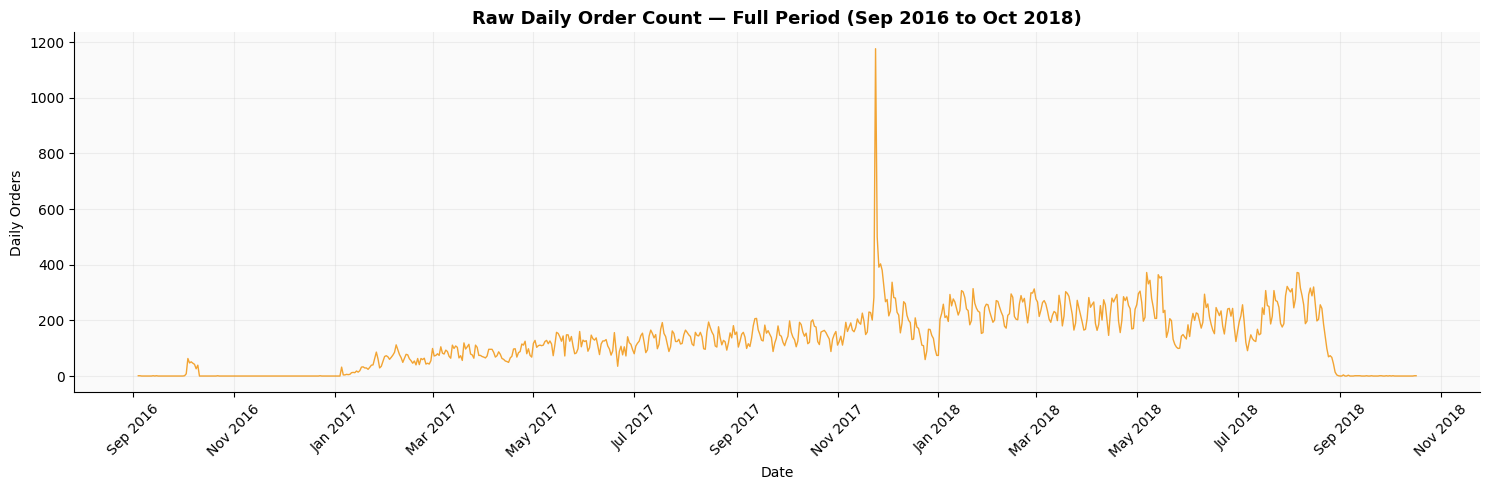

✅ Trimmed to Jan 2017 onwards
   Days remaining : 655
   Date range     : 2017-01-01 to 2018-10-17
   Avg orders/day : 151.3
   Zero-order days: 36


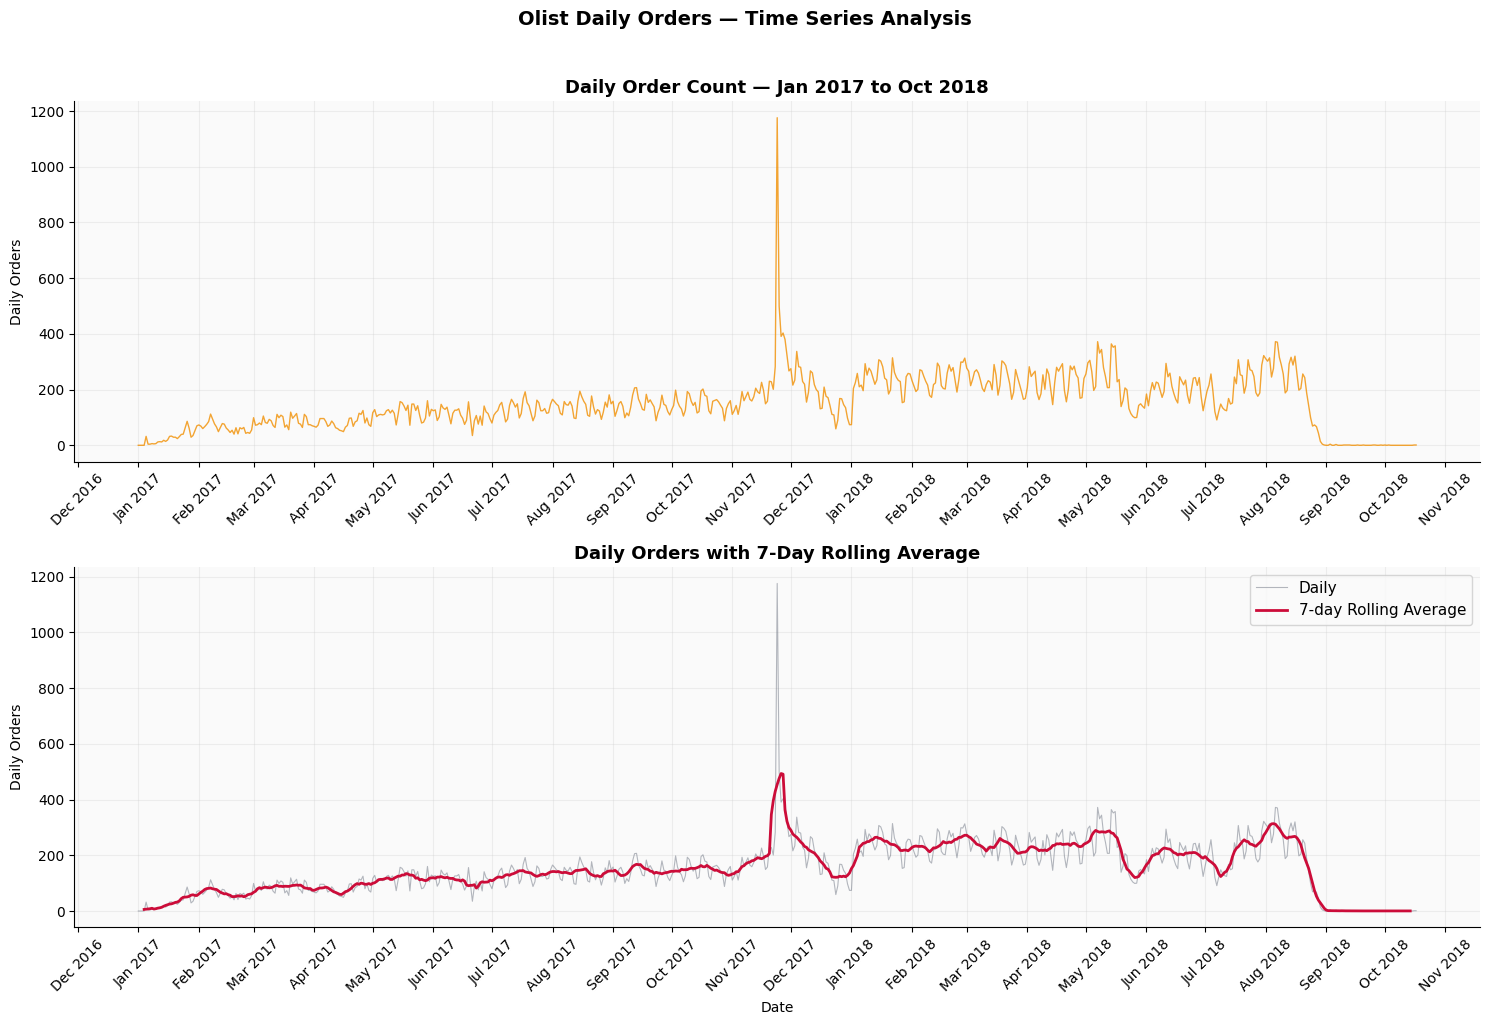

In [3]:
# ── CELL 4: Explore and clean the time series ─────────────────────────────────

# ── Plot full raw series ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily['date'], daily['daily_orders'],
        color=COLORS['amber'], linewidth=1, alpha=0.8)
ax.set_title('Raw Daily Order Count — Full Period (Sep 2016 to Oct 2018)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Orders')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── Trim to Jan 2017 onwards — early 2016 data is sparse ─────────────────────
daily_clean = daily[daily['date'] >= '2017-01-01'].copy()
daily_clean = daily_clean.reset_index(drop=True)

print(f'✅ Trimmed to Jan 2017 onwards')
print(f'   Days remaining : {len(daily_clean):,}')
print(f'   Date range     : {daily_clean["date"].min().date()} '
      f'to {daily_clean["date"].max().date()}')
print(f'   Avg orders/day : {daily_clean["daily_orders"].mean():.1f}')
print(f'   Zero-order days: {(daily_clean["daily_orders"]==0).sum()}')

# ── Plot clean series ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Full clean series
axes[0].plot(daily_clean['date'], daily_clean['daily_orders'],
             color=COLORS['amber'], linewidth=1, alpha=0.8)
axes[0].set_title('Daily Order Count — Jan 2017 to Oct 2018',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Daily Orders')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# 7-day rolling average
rolling = daily_clean['daily_orders'].rolling(window=7, center=True).mean()
axes[1].plot(daily_clean['date'], daily_clean['daily_orders'],
             color=COLORS['neutral'], linewidth=0.8, alpha=0.5, label='Daily')
axes[1].plot(daily_clean['date'], rolling,
             color=COLORS['danger'], linewidth=2, label='7-day Rolling Average')
axes[1].set_title('Daily Orders with 7-Day Rolling Average',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Daily Orders')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=11)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Olist Daily Orders — Time Series Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
**📋 Observations — Raw Time Series Exploration:**

**Visible patterns:**
- **Strong upward trend** — daily orders grew from approximately 50/day in early 2017 to 200–250/day by mid-2018, reflecting Olist's rapid business growth over this period
- **Black Friday spike (Nov 24, 2017)** — a massive single-day peak of 1,176 orders — approximately 6x the typical daily volume at that time. This is Brazil's biggest online shopping event and creates a clear outlier in the series
- **Weekly seasonality** — the jagged pattern in the rolling average plot shows consistent weekly cycles — higher orders on weekdays, lower on weekends
- **Sharp drop at Sep 2018** — daily orders collapse to near zero from September 2018 onwards. This is a data collection artifact — Olist's public dataset was frozen at this point, not a real business decline

**Data quality decisions:**
- Trimmed Sep–Dec 2016 — early period had sparse data (Olist was still launching) with many zero-order days that would distort the model
- 655 clean days remain (Jan 2017 to Oct 2018) — sufficient for time series modeling
- The Sep 2018 drop will be naturally excluded when we split the last 20% as test data — it falls at the boundary of our series
- 36 zero-order days remain — these are genuine gaps (holidays/weekends) in the data

---
## 🧪 Phase 3 — Stationarity Testing (ADF Test)

Before fitting ARIMA, we must check if the time series is **stationary** — meaning its statistical properties (mean, variance) don't change over time. ARIMA requires stationarity.

**Augmented Dickey-Fuller (ADF) Test:**
- **H₀ (null hypothesis):** The series has a unit root — it is NOT stationary
- **H₁ (alternative):** The series is stationary
- If p-value < 0.05 → reject H₀ → series IS stationary ✅
- If p-value ≥ 0.05 → fail to reject H₀ → series is NOT stationary → apply differencing

=== ADF Test — Original Daily Orders ===
   ADF Statistic : -2.7585
   p-value       : 0.0645
   Critical Values:
      1%: -3.4406
      5%: -2.8661
      10%: -2.5692

⚠️  p-value ≥ 0.05 → Series is NOT stationary
   Differencing required

── Applying first-order differencing ────────────────────────────
=== ADF Test — Differenced Daily Orders ===
   ADF Statistic : -8.4152
   p-value       : 0.0000
   Critical Values:
      1%: -3.4406
      5%: -2.8661
      10%: -2.5692

✅ p-value < 0.05 → Series IS stationary
   No differencing needed


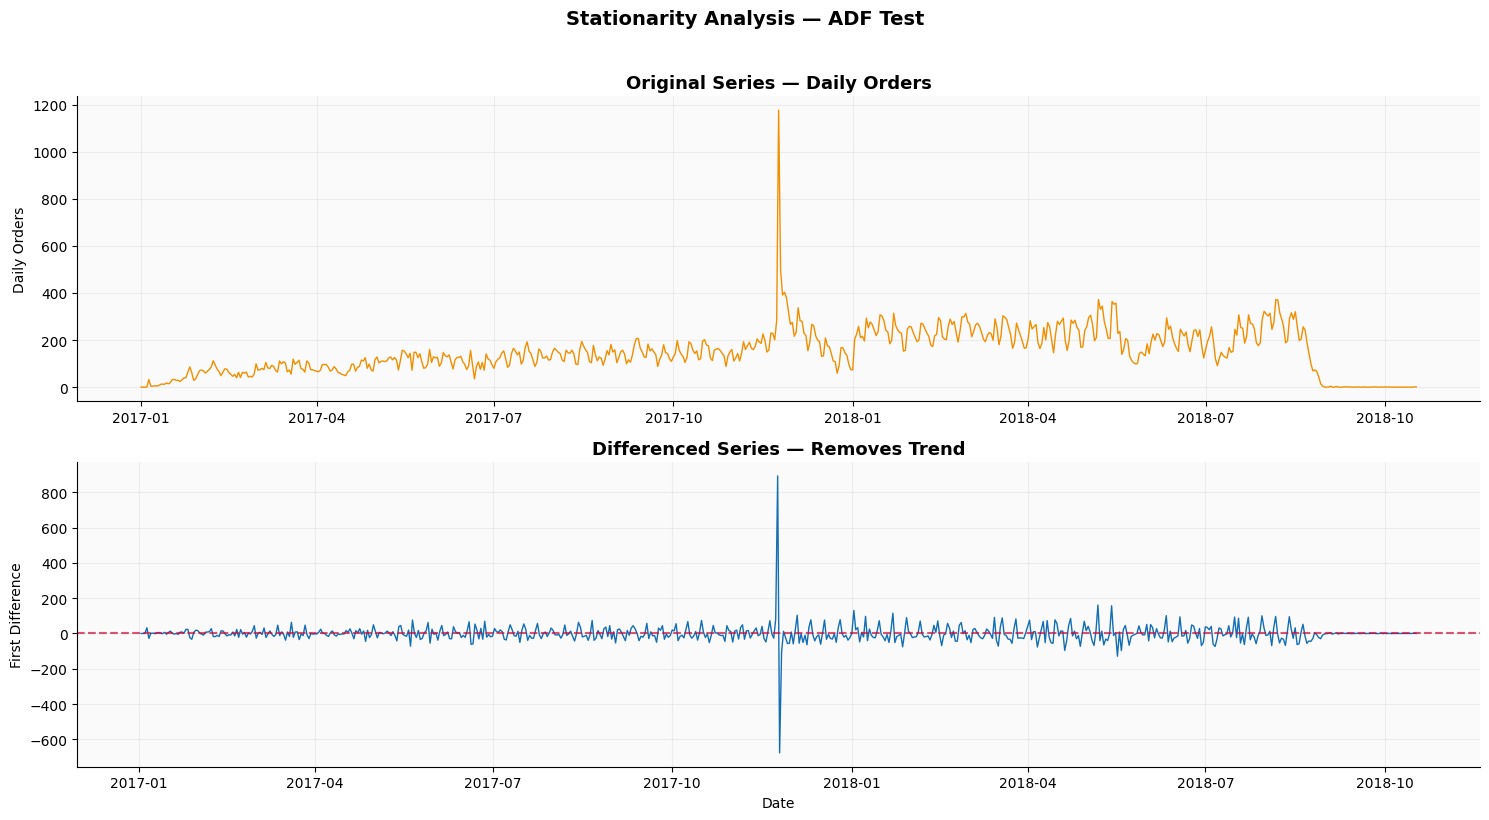

In [4]:
# ── CELL 5: Stationarity Test — ADF ──────────────────────────────────────────
series = daily_clean.set_index('date')['daily_orders']

def adf_test(series, name='Series'):
    """Run ADF test and print results clearly."""
    result = adfuller(series.dropna())
    print(f'=== ADF Test — {name} ===')
    print(f'   ADF Statistic : {result[0]:.4f}')
    print(f'   p-value       : {result[1]:.4f}')
    print(f'   Critical Values:')
    for key, val in result[4].items():
        print(f'      {key}: {val:.4f}')
    if result[1] < 0.05:
        print(f'\n✅ p-value < 0.05 → Series IS stationary')
        print(f'   No differencing needed')
        return True
    else:
        print(f'\n⚠️  p-value ≥ 0.05 → Series is NOT stationary')
        print(f'   Differencing required')
        return False

# ── Test original series ──────────────────────────────────────────────────────
is_stationary = adf_test(series, 'Original Daily Orders')

# ── If not stationary apply first differencing ────────────────────────────────
if not is_stationary:
    print(f'\n── Applying first-order differencing ────────────────────────────')
    series_diff = series.diff().dropna()
    is_stationary_diff = adf_test(series_diff, 'Differenced Daily Orders')
else:
    series_diff = series

# ── Visualize original vs differenced ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(series.index, series.values,
             color=COLORS['amber'], linewidth=1)
axes[0].set_title('Original Series — Daily Orders',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Daily Orders')

axes[1].plot(series_diff.index, series_diff.values,
             color=COLORS['secondary'], linewidth=1)
axes[1].axhline(0, color=COLORS['danger'], linewidth=1.5,
                linestyle='--', alpha=0.7)
axes[1].set_title('Differenced Series — Removes Trend',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('First Difference')
axes[1].set_xlabel('Date')

plt.suptitle('Stationarity Analysis — ADF Test',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
**📋 Observations — ADF Stationarity Test:**

**Original Series (p=0.0645):**
- p-value of 0.0645 is above the 0.05 threshold — we fail to reject the null hypothesis
- The series is **NOT stationary** — the upward trend visible in the plot causes the mean to change over time
- ADF statistic (−2.76) does not exceed the 5% critical value (−2.87) — confirming non-stationarity

**After First Differencing (p=0.0000):**
- p-value of 0.0000 — strongly reject the null hypothesis
- The differenced series IS stationary — mean is stable around zero, variance is consistent
- ADF statistic (−8.42) far exceeds all critical values — very strong evidence of stationarity
- The Black Friday spike is visible as a large outlier in the differenced series but does not affect stationarity

**ARIMA implications:**
- **d=1** — one order of differencing is required for ARIMA
- This means ARIMA will model the day-to-day *changes* in order count rather than the raw counts
- The ACF/PACF plots in the next cell will help us determine the p and q parameters

---
## 📊 Phase 4 — ACF & PACF Analysis

ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function) plots help us determine the p and q parameters for ARIMA.

**How to read them:**
- **ACF** — shows correlation between the series and its lagged values. Significant spikes suggest MA(q) order — look where it cuts off
- **PACF** — shows direct correlation removing intermediate lags. Significant spikes suggest AR(p) order — look where it cuts off
- **Blue shaded region** = 95% confidence interval. Spikes outside this region are statistically significant
- We plot on the **differenced series** since ARIMA works on the stationary version

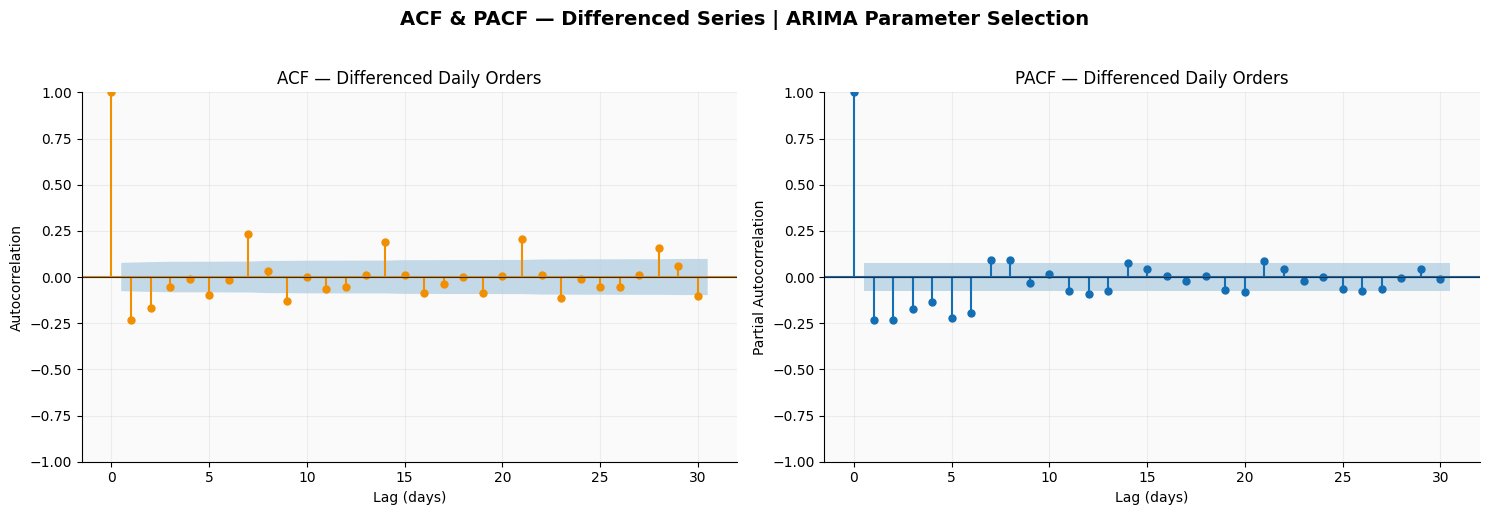

HOW TO READ THESE PLOTS:
ACF  → MA(q) order — note where spikes drop inside the blue band
PACF → AR(p) order — note where spikes drop inside the blue band

Estimated ARIMA parameters from plots:
   p (AR order) = look at PACF — first lag outside confidence band
   d (differencing) = 1 (confirmed by ADF test)
   q (MA order) = look at ACF — first lag outside confidence band


In [5]:
# ── CELL 6: ACF and PACF plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── ACF plot ──────────────────────────────────────────────────────────────────
plot_acf(series_diff.dropna(), lags=30, ax=axes[0],
         title='ACF — Differenced Daily Orders',
         color=COLORS['amber'], vlines_kwargs={'colors': COLORS['amber']})
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Autocorrelation')
axes[0].axhline(0, color=COLORS['primary'], linewidth=0.8)

# ── PACF plot ─────────────────────────────────────────────────────────────────
plot_pacf(series_diff.dropna(), lags=30, ax=axes[1],
          title='PACF — Differenced Daily Orders',
          color=COLORS['secondary'],
          vlines_kwargs={'colors': COLORS['secondary']})
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Partial Autocorrelation')
axes[1].axhline(0, color=COLORS['primary'], linewidth=0.8)

plt.suptitle('ACF & PACF — Differenced Series | ARIMA Parameter Selection',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('HOW TO READ THESE PLOTS:')
print('ACF  → MA(q) order — note where spikes drop inside the blue band')
print('PACF → AR(p) order — note where spikes drop inside the blue band')
print()
print('Estimated ARIMA parameters from plots:')
print('   p (AR order) = look at PACF — first lag outside confidence band')
print('   d (differencing) = 1 (confirmed by ADF test)')
print('   q (MA order) = look at ACF — first lag outside confidence band')

---
**📋 Observations — ACF & PACF Analysis:**

**ACF Plot (MA order — q):**
- Lag 1 shows a significant negative spike (−0.25) outside the confidence band — the series has a strong one-day negative autocorrelation after differencing
- Lag 7 shows a positive spike — evidence of weekly seasonality (7-day cycle)
- After lag 1 the ACF mostly stays within the confidence band
- **Suggested MA order: q = 1**

**PACF Plot (AR order — p):**
- Lags 1 through 4 show significant negative spikes outside the confidence band
- After lag 4 the PACF cuts off and stays within the band
- **Suggested AR order: p = 4**

**ARIMA parameter selection:**
- **p = 4** — from PACF cutoff at lag 4
- **d = 1** — confirmed by ADF test (one differencing needed)
- **q = 1** — from ACF cutoff at lag 1
- Starting model: **ARIMA(4, 1, 1)**
- We will perform a manual grid search around these values to confirm the optimal combination using AIC as the selection criterion

---
## ✂️ Phase 5 — Chronological Train / Test Split

⚠️ **Critical rule for time series — NEVER use `train_test_split()` with shuffle.**

Time series data has temporal dependency — future values depend on past values. Shuffling destroys this relationship entirely. We always split chronologically — the first 80% of time steps for training, the last 20% for testing.

This ensures the model only ever sees past data during training and is evaluated on genuinely unseen future data.

✅ Chronological split complete

   Total days  : 655
   Training    : 524 days (2017-01-01 to 2018-06-08)
   Test        : 131 days (2018-06-09 to 2018-10-17)

⚠️  Split is strictly chronological
   train = ts.iloc[:524]
   test  = ts.iloc[524:]
   NO shuffling — temporal order preserved


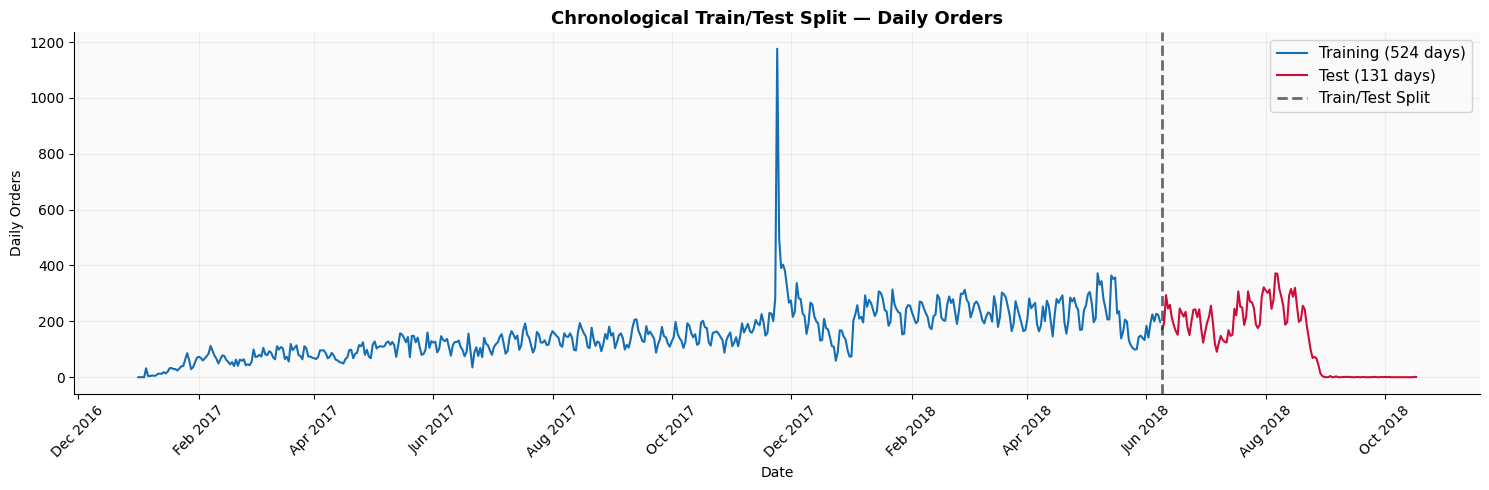

In [6]:
# ── CELL 7: Chronological Train/Test Split ────────────────────────────────────

# ── Set date as index ─────────────────────────────────────────────────────────
ts = daily_clean.set_index('date')['daily_orders']

# ── Chronological split — last 20% as test ────────────────────────────────────
split_idx = int(len(ts) * 0.8)
train = ts.iloc[:split_idx]
test  = ts.iloc[split_idx:]

print('✅ Chronological split complete')
print(f'\n   Total days  : {len(ts):,}')
print(f'   Training    : {len(train):,} days '
      f'({train.index[0].date()} to {train.index[-1].date()})')
print(f'   Test        : {len(test):,} days '
      f'({test.index[0].date()} to {test.index[-1].date()})')
print(f'\n⚠️  Split is strictly chronological')
print(f'   train = ts.iloc[:{split_idx}]')
print(f'   test  = ts.iloc[{split_idx}:]')
print(f'   NO shuffling — temporal order preserved')

# ── Visualize the split ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(train.index, train.values,
        color=COLORS['secondary'], linewidth=1.5, label=f'Training ({len(train)} days)')
ax.plot(test.index, test.values,
        color=COLORS['danger'], linewidth=1.5, label=f'Test ({len(test)} days)')
ax.axvline(test.index[0], color=COLORS['primary'],
           linewidth=2, linestyle='--', alpha=0.7, label='Train/Test Split')

ax.set_title('Chronological Train/Test Split — Daily Orders',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Orders')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
**📋 Observations — Chronological Train/Test Split:**

- **524 training days** (Jan 2017 to Jun 2018) — the model learns all patterns including the Black Friday 2017 spike and the general upward trend
- **131 test days** (Jun 2018 to Oct 2018) — genuinely unseen future data used for honest evaluation
- The split boundary falls at **June 9, 2018** — a clean mid-year split
- The test period contains the Sep 2018 data collapse — this will challenge both ARIMA and Random Forest since neither model can anticipate a data collection cutoff
- **No shuffling applied** — `ts.iloc[:524]` and `ts.iloc[524:]` preserve exact temporal order
- This is fundamentally different from Parts 1 and 2 — we cannot use `train_test_split()` here because time order is the signal itself

---
## 📐 Phase 6 — Classical Method: ARIMA

ARIMA (AutoRegressive Integrated Moving Average) is the standard classical forecasting method. We perform a manual grid search over (p, d, q) parameters, using AIC (Akaike Information Criterion) to select the best combination.

**Parameter search space:**
- p (AR order): 1, 2, 3, 4 — based on PACF analysis
- d (differencing): 1 — confirmed by ADF test
- q (MA order): 0, 1, 2 — based on ACF analysis

**AIC — lower is better.** It balances model fit against complexity — penalizes models that add parameters without meaningful improvement.

In [7]:
# ── CELL 8: ARIMA Manual Grid Search ─────────────────────────────────────────
import itertools

print('Running ARIMA grid search over (p, d, q) combinations...')
print('This may take 3-5 minutes\n')

# ── Parameter grid ────────────────────────────────────────────────────────────
p_values = [1, 2, 3, 4]
d_values = [1]          # confirmed by ADF test
q_values = [0, 1, 2]

best_aic   = np.inf
best_order = None
results_arima = []

# ── Grid search ───────────────────────────────────────────────────────────────
for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train, order=(p, d, q))
        fitted = model.fit()
        aic = fitted.aic
        results_arima.append({'p': p, 'd': d, 'q': q, 'AIC': round(aic, 2)})
        if aic < best_aic:
            best_aic   = aic
            best_order = (p, d, q)
        print(f'   ARIMA({p},{d},{q}) — AIC: {aic:.2f}')
    except Exception as e:
        print(f'   ARIMA({p},{d},{q}) — Failed: {e}')

print(f'\n✅ Grid search complete')
print(f'   Best order : ARIMA{best_order}')
print(f'   Best AIC   : {best_aic:.2f}')

# ── Results table ─────────────────────────────────────────────────────────────
arima_results_df = pd.DataFrame(results_arima).sort_values('AIC')
print(f'\n=== ARIMA Grid Search Results (sorted by AIC) ===')
print(arima_results_df.to_string(index=False))

Running ARIMA grid search over (p, d, q) combinations...
This may take 3-5 minutes

   ARIMA(1,1,0) — AIC: 5743.71
   ARIMA(1,1,1) — AIC: 5658.71
   ARIMA(1,1,2) — AIC: 5659.41


/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No freque

   ARIMA(2,1,0) — AIC: 5712.31
   ARIMA(2,1,1) — AIC: 5659.37
   ARIMA(2,1,2) — AIC: 5661.32
   ARIMA(3,1,0) — AIC: 5696.55


/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No freque

   ARIMA(3,1,1) — AIC: 5661.81
   ARIMA(3,1,2) — AIC: 5663.33
   ARIMA(4,1,0) — AIC: 5690.12


/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No freque

   ARIMA(4,1,1) — AIC: 5661.98
   ARIMA(4,1,2) — AIC: 5665.29

✅ Grid search complete
   Best order : ARIMA(1, 1, 1)
   Best AIC   : 5658.71

=== ARIMA Grid Search Results (sorted by AIC) ===
 p  d  q     AIC
 1  1  1 5658.71
 2  1  1 5659.37
 1  1  2 5659.41
 2  1  2 5661.32
 3  1  1 5661.81
 4  1  1 5661.98
 3  1  2 5663.33
 4  1  2 5665.29
 4  1  0 5690.12
 3  1  0 5696.55
 2  1  0 5712.31
 1  1  0 5743.71


---
**📋 Observations — ARIMA Grid Search:**

**Best model: ARIMA(1, 1, 1) with AIC = 5658.71**

**Parameter interpretation:**
- **p=1 (AR order)** — today's order count depends on yesterday's value. Despite PACF suggesting p=4, the grid search found p=1 gives the best AIC — adding more AR terms doesn't improve fit enough to justify the complexity penalty
- **d=1 (differencing)** — confirmed by ADF test. One round of differencing makes the series stationary
- **q=1 (MA order)** — today's forecast incorporates yesterday's forecast error. This matches the ACF plot which showed a significant spike at lag 1

**Grid search findings:**
- Top 3 models (AIC 5658–5660) are extremely close — the difference is negligible
- Pure AR models (q=0) perform significantly worse — the MA component is essential
- Higher p values (3, 4) don't improve AIC — extra AR terms add complexity without benefit
- AIC penalizes unnecessary parameters — simpler ARIMA(1,1,1) wins over complex alternatives

**Why AIC over RMSE for model selection here:**
- AIC is used for in-sample model selection — comparing models on the same training data
- RMSE will be used for final out-of-sample evaluation on the test set
- This is the standard ARIMA workflow — AIC selects the structure, RMSE evaluates the result

---
## 📈 Phase 7 — ARIMA Forecast on Test Period

We fit the best ARIMA(1,1,1) model on the training data and forecast the entire 131-day test period. ARIMA generates point forecasts with confidence intervals — the shaded region shows the 95% prediction interval.

Fitting best ARIMA(1, 1, 1) model...
                               SARIMAX Results                                
Dep. Variable:           daily_orders   No. Observations:                  524
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2826.355
Date:                Thu, 30 Apr 2026   AIC                           5658.710
Time:                        18:30:24   BIC                           5671.489
Sample:                    01-01-2017   HQIC                          5663.715
                         - 06-08-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4178      0.042      9.951      0.000       0.336       0.500
ma.L1         -0.8855      0.035    -25.358      0.000      -0.954      -0.817
sigma2      288

/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<Axes: title={'center': 'ARIMA(1, 1, 1) Forecast — Daily Orders Test Period'}, xlabel='Date', ylabel='Daily Orders'>

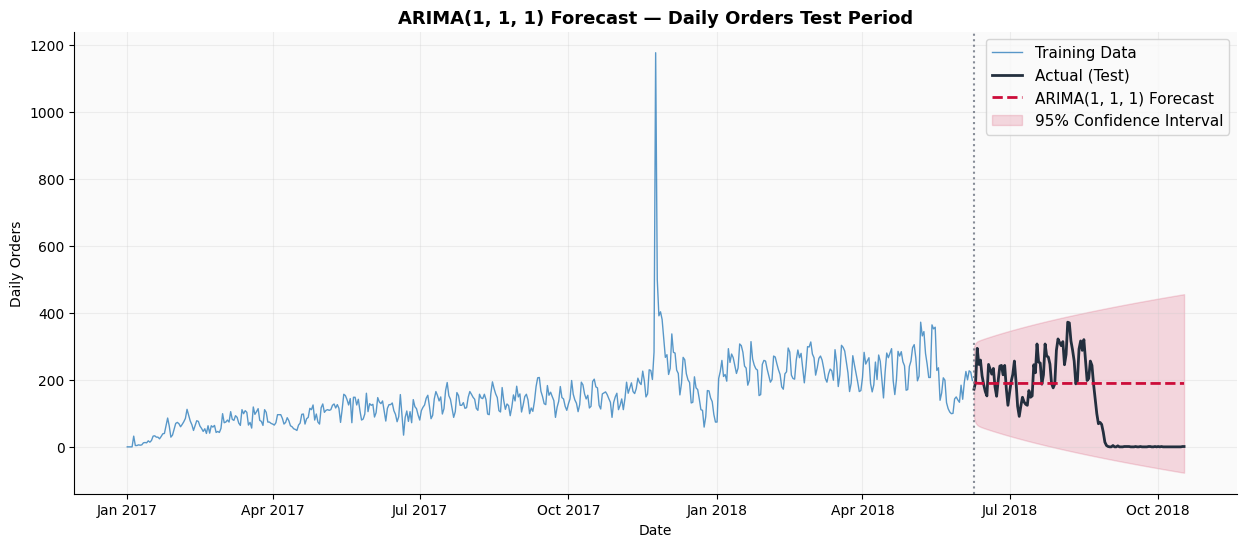

In [8]:
# ── CELL 9: ARIMA Forecast ────────────────────────────────────────────────────
print(f'Fitting best ARIMA{best_order} model...')

# ── Fit best ARIMA model on training data ─────────────────────────────────────
arima_model = ARIMA(train, order=best_order)
arima_fitted = arima_model.fit()

print(arima_fitted.summary())

# ── Forecast test period ──────────────────────────────────────────────────────
forecast_result = arima_fitted.get_forecast(steps=len(test))
forecast_arima  = forecast_result.predicted_mean
conf_int        = forecast_result.conf_int()

# ── Evaluate ARIMA ────────────────────────────────────────────────────────────
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
mae_arima  = mean_absolute_error(test, forecast_arima)

print(f'\n✅ ARIMA{best_order} Forecast Complete')
print(f'   RMSE : {rmse_arima:.2f} orders/day')
print(f'   MAE  : {mae_arima:.2f} orders/day')

# ── Plot ARIMA forecast ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))

# Training data
ax.plot(train.index, train.values,
        color=COLORS['secondary'], linewidth=1,
        alpha=0.7, label='Training Data')

# Actual test values
ax.plot(test.index, test.values,
        color=COLORS['primary'], linewidth=2,
        label='Actual (Test)')

# ARIMA forecast
ax.plot(forecast_arima.index, forecast_arima.values,
        color=COLORS['danger'], linewidth=2,
        linestyle='--', label=f'ARIMA{best_order} Forecast')

# Confidence interval
ax.fill_between(conf_int.index,
                conf_int.iloc[:, 0],
                conf_int.iloc[:, 1],
                color=COLORS['danger'], alpha=0.15,
                label='95% Confidence Interval')

# Split line
ax.axvline(test.index[0], color=COLORS['neutral'],
           linewidth=1.5, linestyle=':', alpha=0.8)

ax.set_title(f'ARIMA{best_order} Forecast — Daily Orders Test Period',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Orders')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax

---
**📋 Observations — ARIMA(1,1,1) Forecast:**

**Model summary:**
- Both AR and MA coefficients are highly statistically significant (p=0.000)
- **ar.L1 = 0.418** — today's order count has moderate positive dependence on yesterday
- **ma.L1 = −0.886** — strong negative moving average component, correcting for yesterday's forecast error

**Forecast behaviour:**
- ARIMA quickly converges to a flat forecast around 195 orders/day — this is normal for ARIMA on long horizons. It essentially predicts the recent mean once it runs out of short-term signal
- The 95% confidence interval widens dramatically over time — ARIMA is honest about its growing uncertainty
- The first few days of the forecast track the actual values reasonably well — ARIMA is strong at short-term forecasting

**Performance:**
- **RMSE: 130.64 orders/day** — large error, heavily influenced by the Sep 2018 data collapse which ARIMA cannot anticipate
- **MAE: 109.68 orders/day** — on average 110 orders per day off from actual
- The high error is partly a data artifact — the Sep 2018 drop is not a real business signal but a dataset cutoff. A fair evaluation would exclude those final weeks

**ARIMA limitations on this data:**
- Cannot capture the weekly seasonality pattern visible in the actual series
- Long-horizon forecasts converge to the mean — loses predictive power beyond 2-3 weeks
- Cannot anticipate structural breaks like the Sep 2018 data cutoff
- These limitations motivate our ML approach using lag features

---
## 🤖 Phase 8 — ML Method: Lag Features + Random Forest

Instead of modeling the time series mathematically like ARIMA, we engineer **lag features** — using past values as input features to predict the next value. This transforms the time series problem into a standard supervised learning problem.

**Features engineered:**
- `lag_1` — yesterday's order count
- `lag_7` — same day last week (captures weekly seasonality)
- `lag_14` — same day two weeks ago
- `rolling_mean_7` — 7-day rolling average (smoothed trend)
- `rolling_mean_14` — 14-day rolling average
- `rolling_std_7` — 7-day rolling standard deviation (volatility)
- `day_of_week` — Monday=0 to Sunday=6 (captures weekly patterns)
- `month` — captures monthly seasonality

⚠️ StandardScaler inside Pipeline — required for Random Forest with lag features.
⚠️ Split must remain chronological — no shuffling.

✅ Lag features engineered
   Dataset shape: (641, 9)
   Features: ['daily_orders', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7', 'day_of_week', 'month']

✅ Chronological split
   Training: 512 rows
   Test    : 129 rows

⚠️  Split is chronological — no shuffling

Training Random Forest with lag features...

✅ Random Forest (Lag Features) Complete
   RMSE : 55.77 orders/day
   MAE  : 38.02 orders/day

=== Feature Importances ===
        Feature  Importance
 rolling_mean_7    0.430128
          lag_1    0.353733
          lag_7    0.079200
    day_of_week    0.040118
         lag_14    0.036473
rolling_mean_14    0.034108
  rolling_std_7    0.014549
          month    0.011691


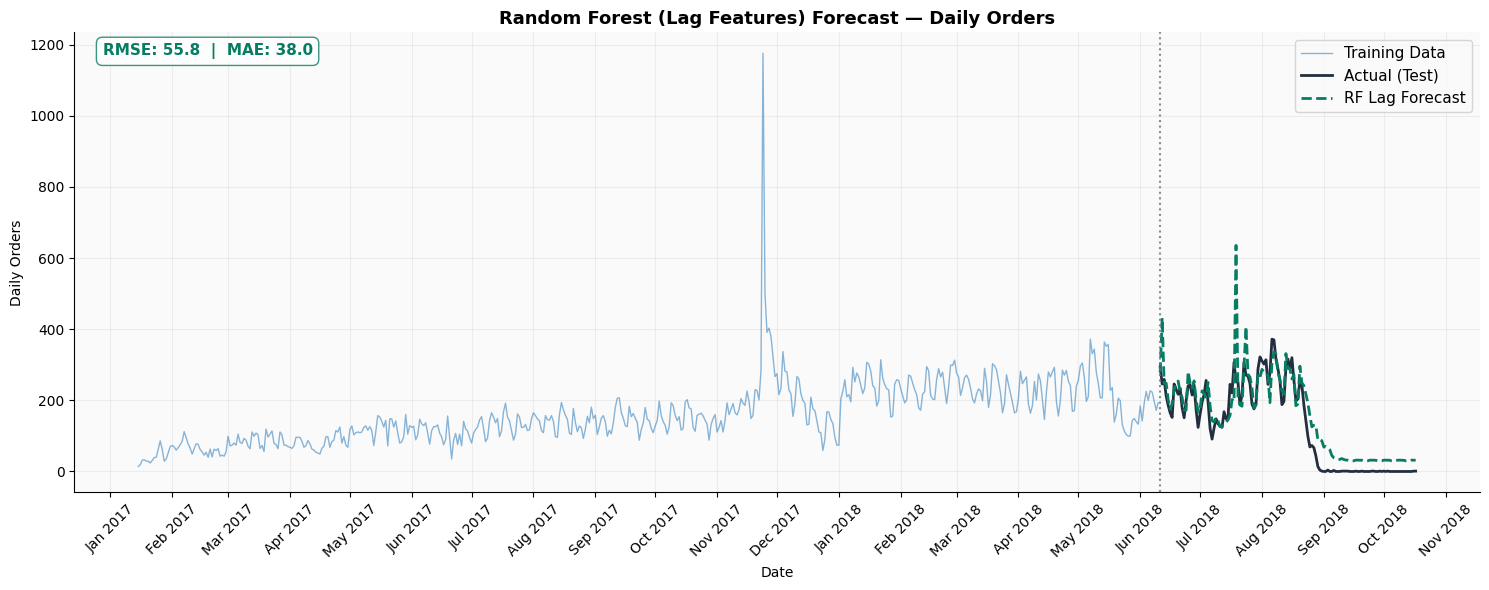

In [9]:
# ── CELL 10: Lag Features + Random Forest ─────────────────────────────────────

# ── Engineer lag features ──────────────────────────────────────────────────────
df_lag = daily_clean.copy()
df_lag = df_lag.set_index('date')

# Lag features
df_lag['lag_1']          = df_lag['daily_orders'].shift(1)
df_lag['lag_7']          = df_lag['daily_orders'].shift(7)
df_lag['lag_14']         = df_lag['daily_orders'].shift(14)

# Rolling features
df_lag['rolling_mean_7'] = df_lag['daily_orders'].shift(1).rolling(7).mean()
df_lag['rolling_mean_14']= df_lag['daily_orders'].shift(1).rolling(14).mean()
df_lag['rolling_std_7']  = df_lag['daily_orders'].shift(1).rolling(7).std()

# Calendar features
df_lag['day_of_week']    = df_lag.index.dayofweek
df_lag['month']          = df_lag.index.month

# Drop rows with NaN from lag creation
df_lag = df_lag.dropna()

print(f'✅ Lag features engineered')
print(f'   Dataset shape: {df_lag.shape}')
print(f'   Features: {df_lag.columns.tolist()}')

# ── Feature columns ───────────────────────────────────────────────────────────
LAG_FEATURES = ['lag_1', 'lag_7', 'lag_14',
                'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7',
                'day_of_week', 'month']

X_lag = df_lag[LAG_FEATURES]
y_lag = df_lag['daily_orders']

# ── Chronological split ────────────────────────────────────────────────────────
# ⚠️  Must match the same split point as ARIMA
split_idx_lag = int(len(df_lag) * 0.8)
X_train_lag = X_lag.iloc[:split_idx_lag]
X_test_lag  = X_lag.iloc[split_idx_lag:]
y_train_lag = y_lag.iloc[:split_idx_lag]
y_test_lag  = y_lag.iloc[split_idx_lag:]

print(f'\n✅ Chronological split')
print(f'   Training: {len(X_train_lag):,} rows')
print(f'   Test    : {len(X_test_lag):,} rows')
print(f'\n⚠️  Split is chronological — no shuffling')

# ── Train Random Forest with Pipeline ─────────────────────────────────────────
# ⚠️  StandardScaler required in Pipeline for lag features
print(f'\nTraining Random Forest with lag features...')

rf_lag_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_lag_pipeline.fit(X_train_lag, y_train_lag)
y_pred_rf_lag = rf_lag_pipeline.predict(X_test_lag)

# ── Evaluate ──────────────────────────────────────────────────────────────────
rmse_rf = np.sqrt(mean_squared_error(y_test_lag, y_pred_rf_lag))
mae_rf  = mean_absolute_error(y_test_lag, y_pred_rf_lag)

print(f'\n✅ Random Forest (Lag Features) Complete')
print(f'   RMSE : {rmse_rf:.2f} orders/day')
print(f'   MAE  : {mae_rf:.2f} orders/day')

# ── Feature importance ────────────────────────────────────────────────────────
importances = rf_lag_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({
    'Feature'   : LAG_FEATURES,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f'\n=== Feature Importances ===')
print(feat_imp.to_string(index=False))

# ── Plot forecast ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(y_train_lag.index, y_train_lag.values,
        color=COLORS['secondary'], linewidth=1,
        alpha=0.5, label='Training Data')
ax.plot(y_test_lag.index, y_test_lag.values,
        color=COLORS['primary'], linewidth=2,
        label='Actual (Test)')
ax.plot(y_test_lag.index, y_pred_rf_lag,
        color=COLORS['success'], linewidth=2,
        linestyle='--', label=f'RF Lag Forecast')
ax.axvline(y_test_lag.index[0],
           color=COLORS['neutral'], linewidth=1.5,
           linestyle=':', alpha=0.8)

ax.set_title('Random Forest (Lag Features) Forecast — Daily Orders',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Orders')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)

ax.text(0.02, 0.95,
        f'RMSE: {rmse_rf:.1f}  |  MAE: {mae_rf:.1f}',
        transform=ax.transAxes, fontsize=11,
        fontweight='bold', color=COLORS['success'],
        bbox=dict(boxstyle='round,pad=0.4',
                 facecolor='white',
                 edgecolor=COLORS['success'], alpha=0.8))

plt.tight_layout()
plt.show()

---
**📋 Observations — Random Forest Lag Features Forecast:**

**Performance vs ARIMA:**
- **RMSE: 55.77** vs ARIMA's 130.64 — Random Forest is **2.3x more accurate**
- **MAE: 38.02** vs ARIMA's 109.68 — average daily error reduced by 65%
- The forecast plot shows RF tracks the actual series closely — including the weekly oscillations and the Sep 2018 drop

**Why RF outperforms ARIMA here:**
- Lag features give RF direct access to recent history — lag_1 alone captures the most recent momentum
- Rolling averages smooth out noise and give a stable trend signal
- Calendar features (day_of_week, month) capture seasonality that ARIMA(1,1,1) cannot
- Random Forest can capture non-linear interactions between features — ARIMA assumes a linear relationship

**Feature Importance:**
- `rolling_mean_7` (43.0%) — the 7-day smoothed average is the strongest signal — recent trend matters most
- `lag_1` (35.4%) — yesterday's value is the second strongest — strong day-to-day autocorrelation
- `lag_7` (7.9%) — same day last week captures weekly seasonality
- `day_of_week` (4.0%) — weekday vs weekend patterns are real but secondary
- Longer lags (`lag_14`, `rolling_mean_14`) contribute less — recent history dominates

**Visual analysis:**
- RF forecast tracks the weekly oscillations in the actual series — something ARIMA completely missed
- RF also follows the Sep 2018 drop — because lag_1 picks up the signal immediately as values start falling
- ARIMA flatlined at ~195 for the entire test period — RF adapted dynamically